# OPHELIA DANKYI


In [1]:
# Install CmdStanPy for Google Colab
!curl -O "https://raw.githubusercontent.com/MLGlobalHealth/StatML4PopHealth/main/practicals/resources/scripts/utilities.py"
from utilities import custom_install_cmdstan, test_cmdstan_installation
custom_install_cmdstan()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  2066  100  2066    0     0   4760      0 --:--:-- --:--:-- --:--:--  4771
Installing cmdstanpy==1.2.5
colab-cmdstan-2.36.0.tar.gz has already been downloaded
Unpacking colab-cmdstan-2.36.0.tar.gz
Installing required libtbb2 Linux package
Setting cmdstan path
CmdStan successfully installed!


In [2]:
!pip install -q cmdstanpy

In [3]:
import pandas as pd
import numpy as np
from cmdstanpy import CmdStanModel
import arviz as az
from sklearn.preprocessing import StandardScaler
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd
import numpy as np
import arviz as az

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Aesthetics
sns.set_theme(style="whitegrid")
plt.rc('axes', titlesize=10, labelsize=9)
plt.rc('xtick', labelsize=8)
plt.rc('ytick', labelsize=8)

In [4]:
africa = pd.read_csv('https://raw.githubusercontent.com/MLGlobalHealth/StatML4PopHealth/refs/heads/main/data/africa_who_life_expectancy.csv')
africa

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Comoros,East Africa,2007,66.8,91.9,255.8815,0.150,75,64,23.5,...,75,0.02,1166,0.64,7.3,7.2,3.5,0,1,60.7
1,Gabon,Central Africa,2012,39.1,57.1,256.8800,7.470,82,64,24.9,...,82,1.57,7181,1.75,6.3,6.2,7.8,0,1,62.9
2,Ghana,West Africa,2011,45.2,65.9,257.0865,1.670,91,58,23.7,...,91,0.93,1580,25.39,6.9,6.8,6.8,0,1,61.4
3,"Congo, Rep.",Central Africa,2003,64.6,100.2,406.7020,0.900,71,64,22.3,...,50,2.23,2072,3.41,9.1,8.8,5.7,0,1,53.8
4,Madagascar,Southern Africa,2011,45.8,67.0,237.6755,0.890,73,64,21.1,...,73,0.15,464,21.74,7.5,7.4,6.1,0,1,63.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,Seychelles,East Africa,2004,11.8,13.7,169.3040,6.560,99,99,25.8,...,99,3.50,9944,0.08,6.0,6.4,7.7,0,1,72.7
812,Burkina Faso,West Africa,2006,78.1,146.3,300.2140,5.670,76,31,21.5,...,86,0.53,534,13.83,1.0,9.6,1.3,0,1,54.1
813,Mozambique,Southern Africa,2004,90.8,138.2,428.0340,0.590,76,64,21.9,...,83,3.50,370,19.91,3.9,3.8,2.8,0,1,50.1
814,Nigeria,West Africa,2012,81.9,131.1,368.5870,4.730,42,64,23.1,...,42,0.70,2501,167.23,1.7,1.6,5.7,0,1,51.8


## 1. Exploratory Data Analysis

Check for missing values and column names.

In [5]:
print(africa.columns)
print(africa.isnull().sum())


Index(['Country', 'Region', 'Year', 'Infant_deaths', 'Under_five_deaths',
       'Adult_mortality', 'Alcohol_consumption', 'Hepatitis_B', 'Measles',
       'BMI', 'Polio', 'Diphtheria', 'Incidents_HIV', 'GDP_per_capita',
       'Population_mln', 'Thinness_ten_nineteen_years',
       'Thinness_five_nine_years', 'Schooling', 'Economy_status_Developed',
       'Economy_status_Developing', 'Life_expectancy'],
      dtype='object')
Country                        0
Region                         0
Year                           0
Infant_deaths                  0
Under_five_deaths              0
Adult_mortality                0
Alcohol_consumption            0
Hepatitis_B                    0
Measles                        0
BMI                            0
Polio                          0
Diphtheria                     0
Incidents_HIV                  0
GDP_per_capita                 0
Population_mln                 0
Thinness_ten_nineteen_years    0
Thinness_five_nine_years       0
Schoolin

The dataset contains no missing values across any of the columns, ensuring completeness for analysis. All health and demographic variables are fully observed. Subsequent analyses can be conducted without the need for data imputation or exclusion of records


### 1.1 Temporal Analysis of Life Expectancy

Visualizing temporal trends for life expectancy


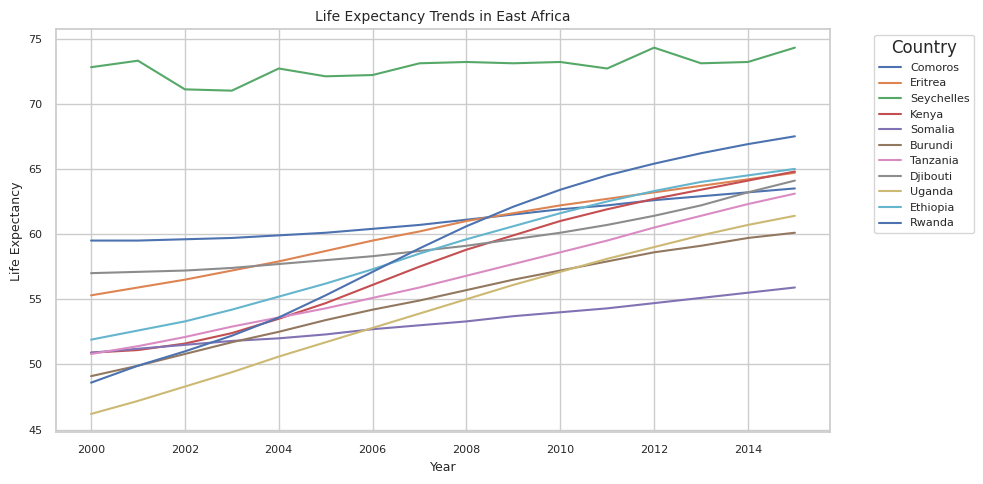

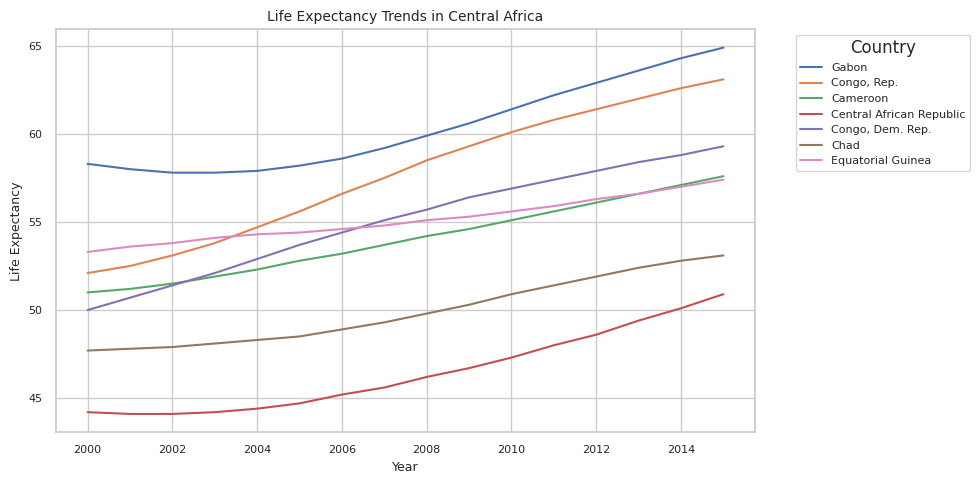

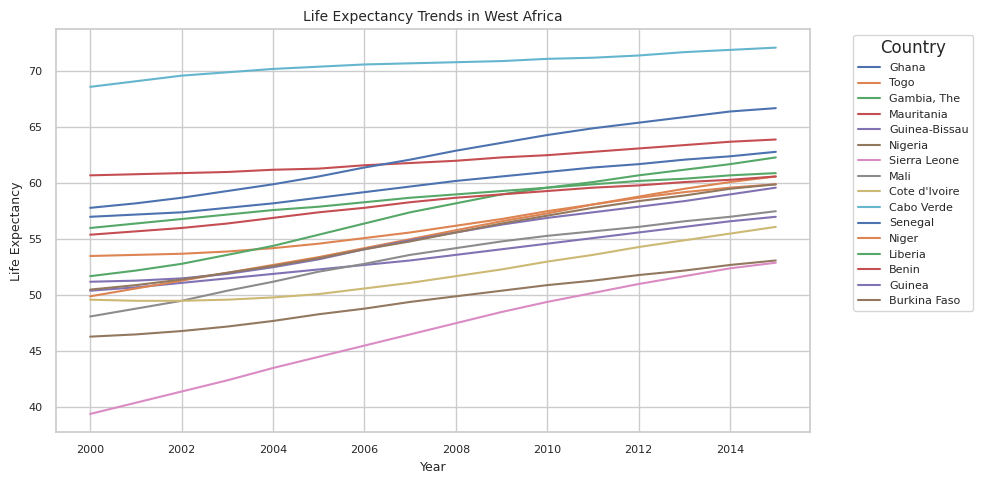

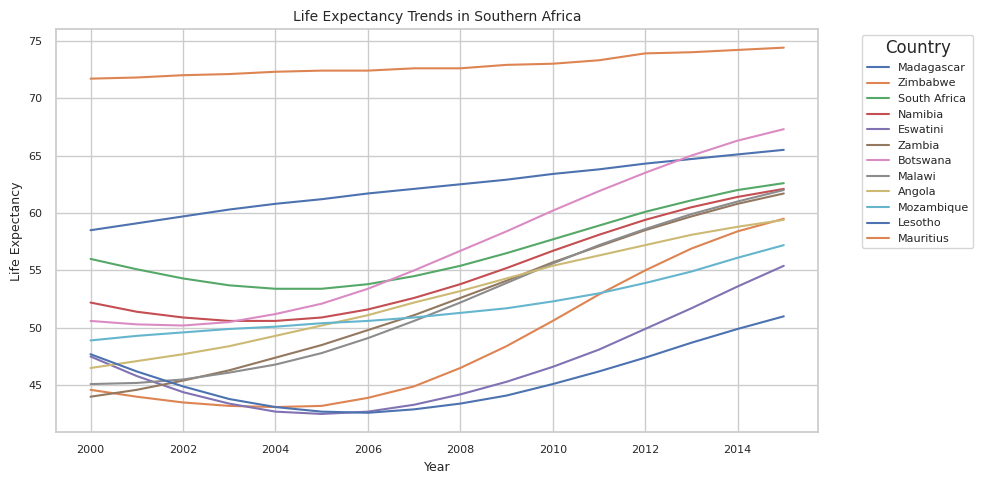

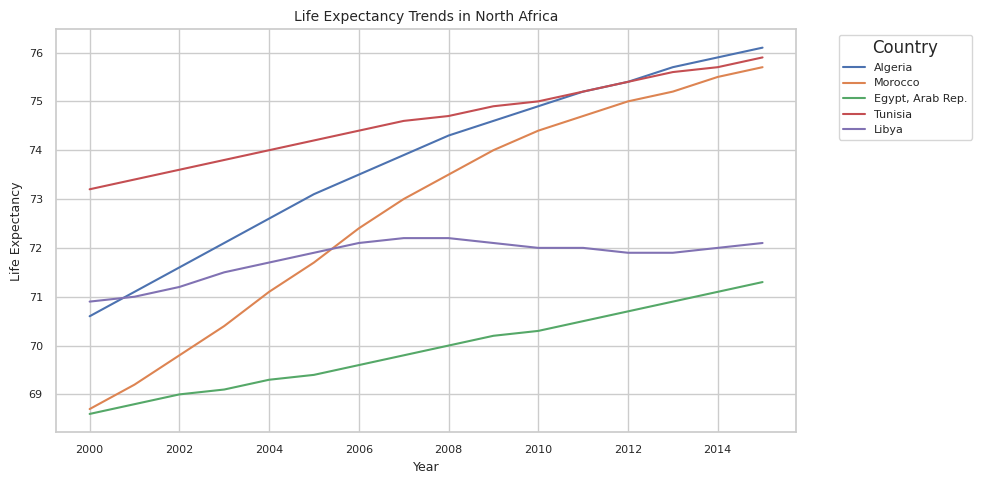

In [6]:
for region in africa['Region'].unique():
    plt.figure(figsize=(10, 5))
    region_data = africa[africa['Region'] == region]

    for country in region_data['Country'].unique():
        subset = region_data[region_data['Country'] == country].sort_values(by='Year')
        plt.plot(subset['Year'], subset['Life_expectancy'], label=country)

    plt.title(f'Life Expectancy Trends in {region}')
    plt.xlabel('Year')
    plt.ylabel('Life Expectancy')
    plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

Across all African regions, a general upward trend in life expectancy is observed from 2000 to 2015. This indicates gradual improvements in health outcomes.
North African countries such as Algeria, Morocco, and Tunisia show consistently high life expectancy, reflecting relatively stronger health systems and socioeconomic conditions.

In contrast, Central and West African countries generally start from lower baselines, some like the Democratic Republic of Congo (Central Africa) and Burkina Faso (West Africa) exhibit slower gains, likely due to political instability and limited healthcare access.

In Southern Africa, countries such as Lesotho and Zimbabwe exhibit anomalously low life expectancies in the early 2000s, followed by sharp improvements, possibly linked to the rollout of HIV/AIDS interventions.

East Africa shows steady improvements overall, with countries like Ethiopia, Rwanda, and Uganda making significant gains, likely driven by public health initiatives and development investments. Meanwhile, Seychelles remains a positive outlier with consistently high life expectancy.

These deviations pointsss out the impact of healthcare policies, economic disparities, and regional crises on population health.

By Country

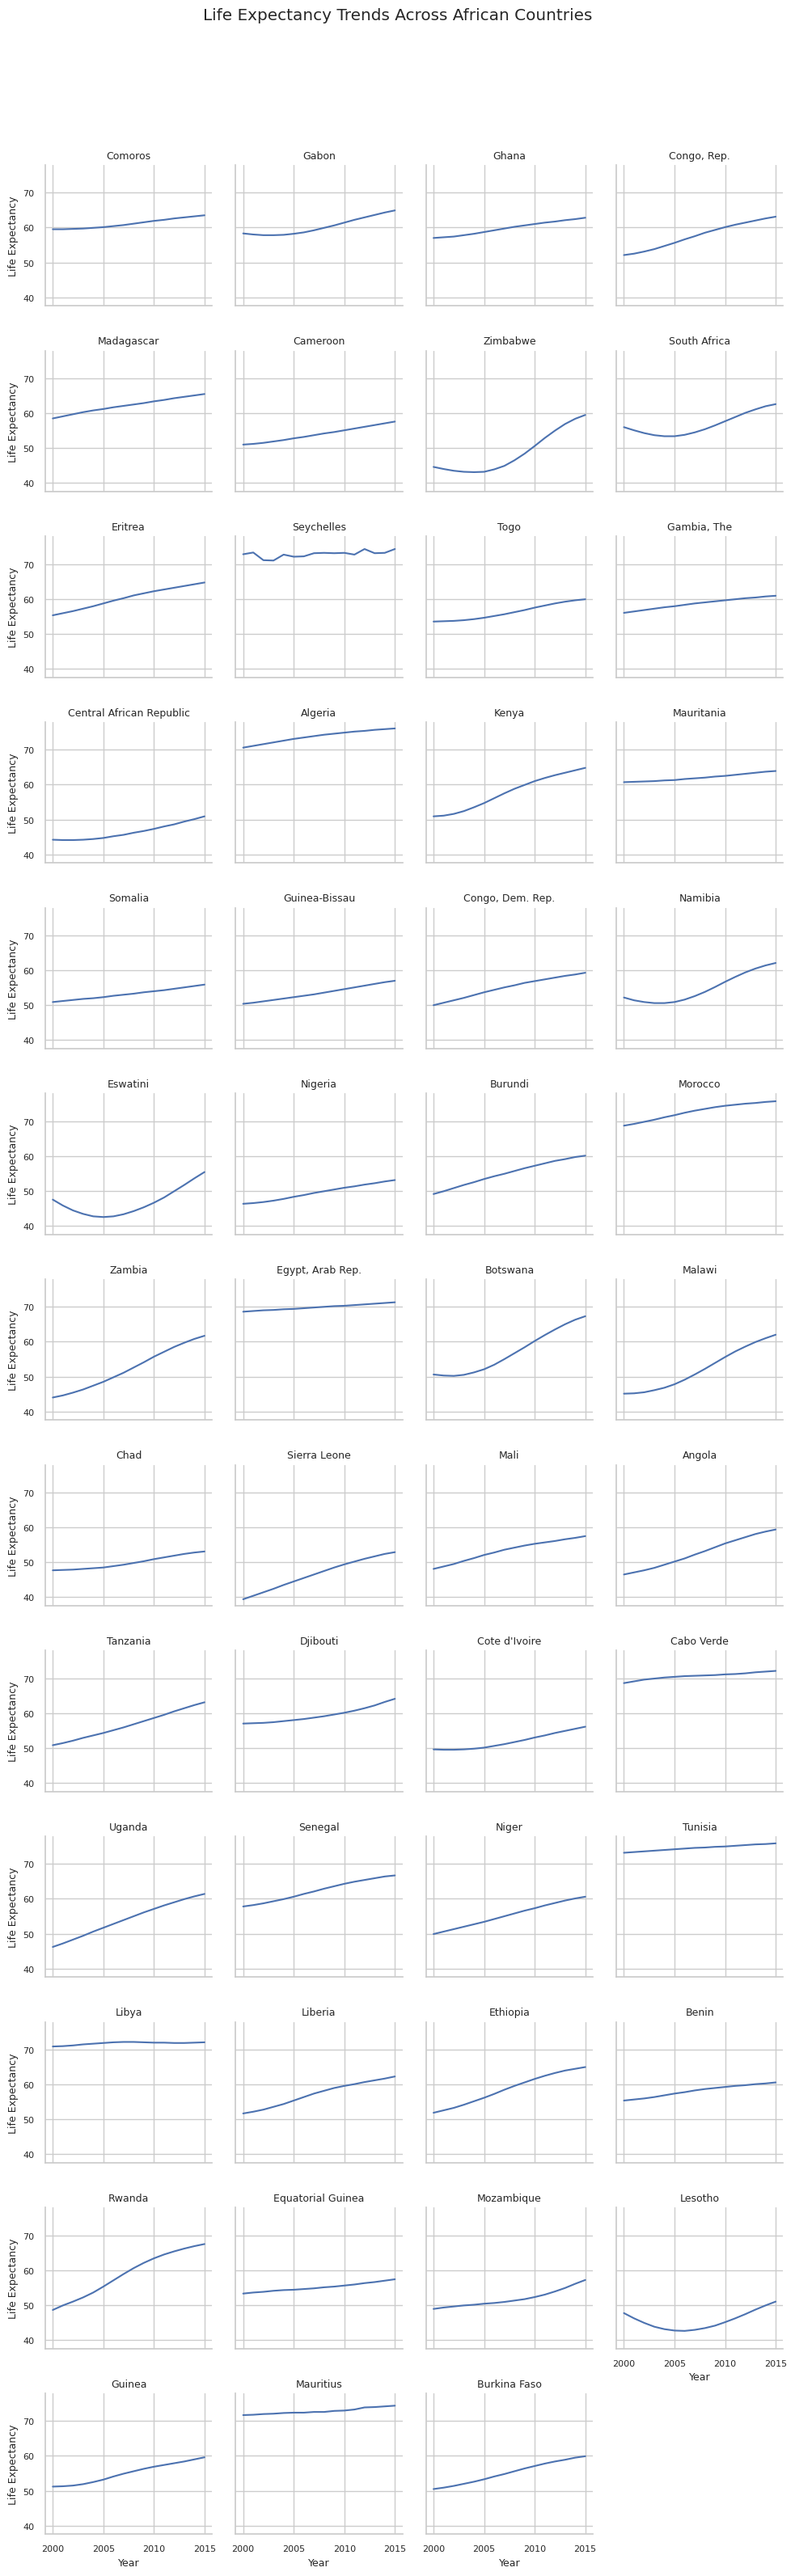

In [7]:
g = sns.FacetGrid(africa, col="Country", col_wrap=4, height=2.5, sharey=True)
g.map(sns.lineplot, "Year", "Life_expectancy")
g.set_titles("{col_name}")
g.set_axis_labels("Year", "Life Expectancy")
plt.subplots_adjust(top=0.92)
g.fig.suptitle("Life Expectancy Trends Across African Countries")
plt.show()


#### Countries that exhibit anomalous patterns and potential explanatory factors
---

This reveals a general upward trend in life expectancy across most African countries from 2000 to 2015, suggesting improvements in healthcare and living conditions. However, a few countries such as Lesotho, Zimbabwe, Eswatini,  and South Africa display noticeable declines or stagnation in the early 2000s, likely due to the HIV/AIDS epidemic and healthcare system challenges. In contrast, countries like Seychelles, Mauritius, and Algeria consistently show high life expectancy, reflecting stronger socioeconomic conditions and health infrastructure. These patterns underscore the influence of regional disparities, public health policies, and economic development on population health outcomes.


Selected_countries - "South Africa", "Eswatini", "Zimbabwe".

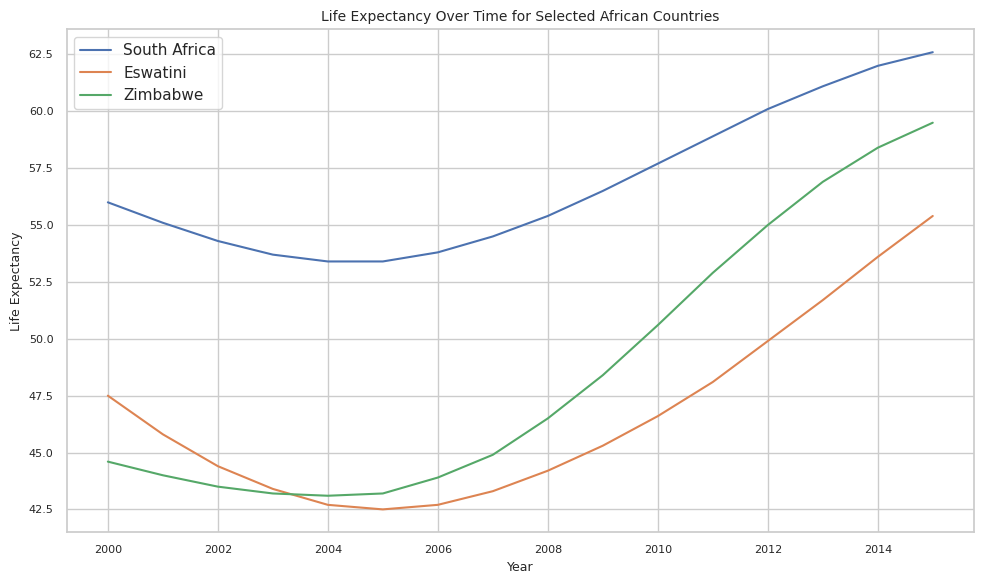

In [8]:
selected_countries = ['South Africa', "Eswatini", "Zimbabwe"]

plt.figure(figsize=(10, 6))
for country in selected_countries:
    subset = africa[africa['Country'] == country].sort_values(by=['Country', 'Year'])
    plt.plot(subset['Year'], subset['Life_expectancy'], label=country)

plt.title('Life Expectancy Over Time for Selected African Countries')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')
plt.legend()
plt.tight_layout()
plt.show()


The graph shows that South Africa's life expectancy steadily increased from 2000 to 2015, Eswatini's life expectancy initially declined before gradually improving, while Zimbabwe's life expectancy showed a sharp decline in the early 2000s, followed by a steady increase afterward

### 1.2 Analysis of Variable relationship

---
Examine the associations between `Life_expectancy` and the remaining variables in the dataset using appropriate visualization techniques such as scatter plots, box plots, or other relevant methods. As a preliminary step, subset the dataset to include only observations from the year 2008. Identify and describe the patterns that emerge, highlighting any variables that exhibit a particularly strong or consistent relationship with life expectancy. Provide an academic discussion on the potential underlying factors—whether socioeconomic, demographic, or health-related—that might explain these observed relationships.

In [9]:
subset = africa[africa['Year'] == 2008].reset_index(drop=True)

In [10]:
subset

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Togo,West Africa,2008,61.4,94.4,318.7475,1.440,82,64,22.9,...,81,1.45,456,6.08,7.7,7.6,4.3,0,1,56.2
1,Somalia,East Africa,2008,101.1,166.5,331.4010,0.000,42,64,22.7,...,31,0.13,265,11.40,7.2,7.0,2.1,0,1,53.3
2,Benin,West Africa,2008,72.2,113.7,259.3400,1.380,75,83,22.9,...,75,0.65,1001,8.70,8.1,8.0,2.8,0,1,58.7
3,Tanzania,East Africa,2008,51.0,79.6,345.9945,4.960,86,64,22.7,...,86,2.76,765,41.85,7.3,7.3,5.0,0,1,56.8
4,"Congo, Dem. Rep.",Central Africa,2008,88.1,122.3,292.7370,3.230,65,64,21.4,...,65,0.62,392,60.41,1.8,1.7,5.0,0,1,55.7
5,Central African Republic,Central Africa,2008,102.5,152.8,494.9685,1.730,45,64,22.2,...,45,2.28,480,4.27,9.3,9.2,3.4,0,1,46.2
6,Lesotho,Southern Africa,2008,77.1,113.0,569.1065,2.910,88,80,24.5,...,88,14.53,962,1.99,8.0,7.8,5.4,0,1,43.4
7,Zambia,Southern Africa,2008,54.5,88.7,442.7350,2.660,87,39,22.0,...,87,6.29,1068,12.85,6.8,6.7,6.5,0,1,52.6
8,Mali,West Africa,2008,81.1,140.2,289.5660,0.580,74,64,22.4,...,74,0.62,707,14.11,9.2,9.0,1.9,0,1,54.2
9,Zimbabwe,Southern Africa,2008,54.5,94.5,594.7345,2.820,75,64,23.6,...,75,7.81,850,12.38,7.8,7.8,7.0,0,1,46.5


The subset dataFrame includes only rows where the year is 2008 and resetting the index.

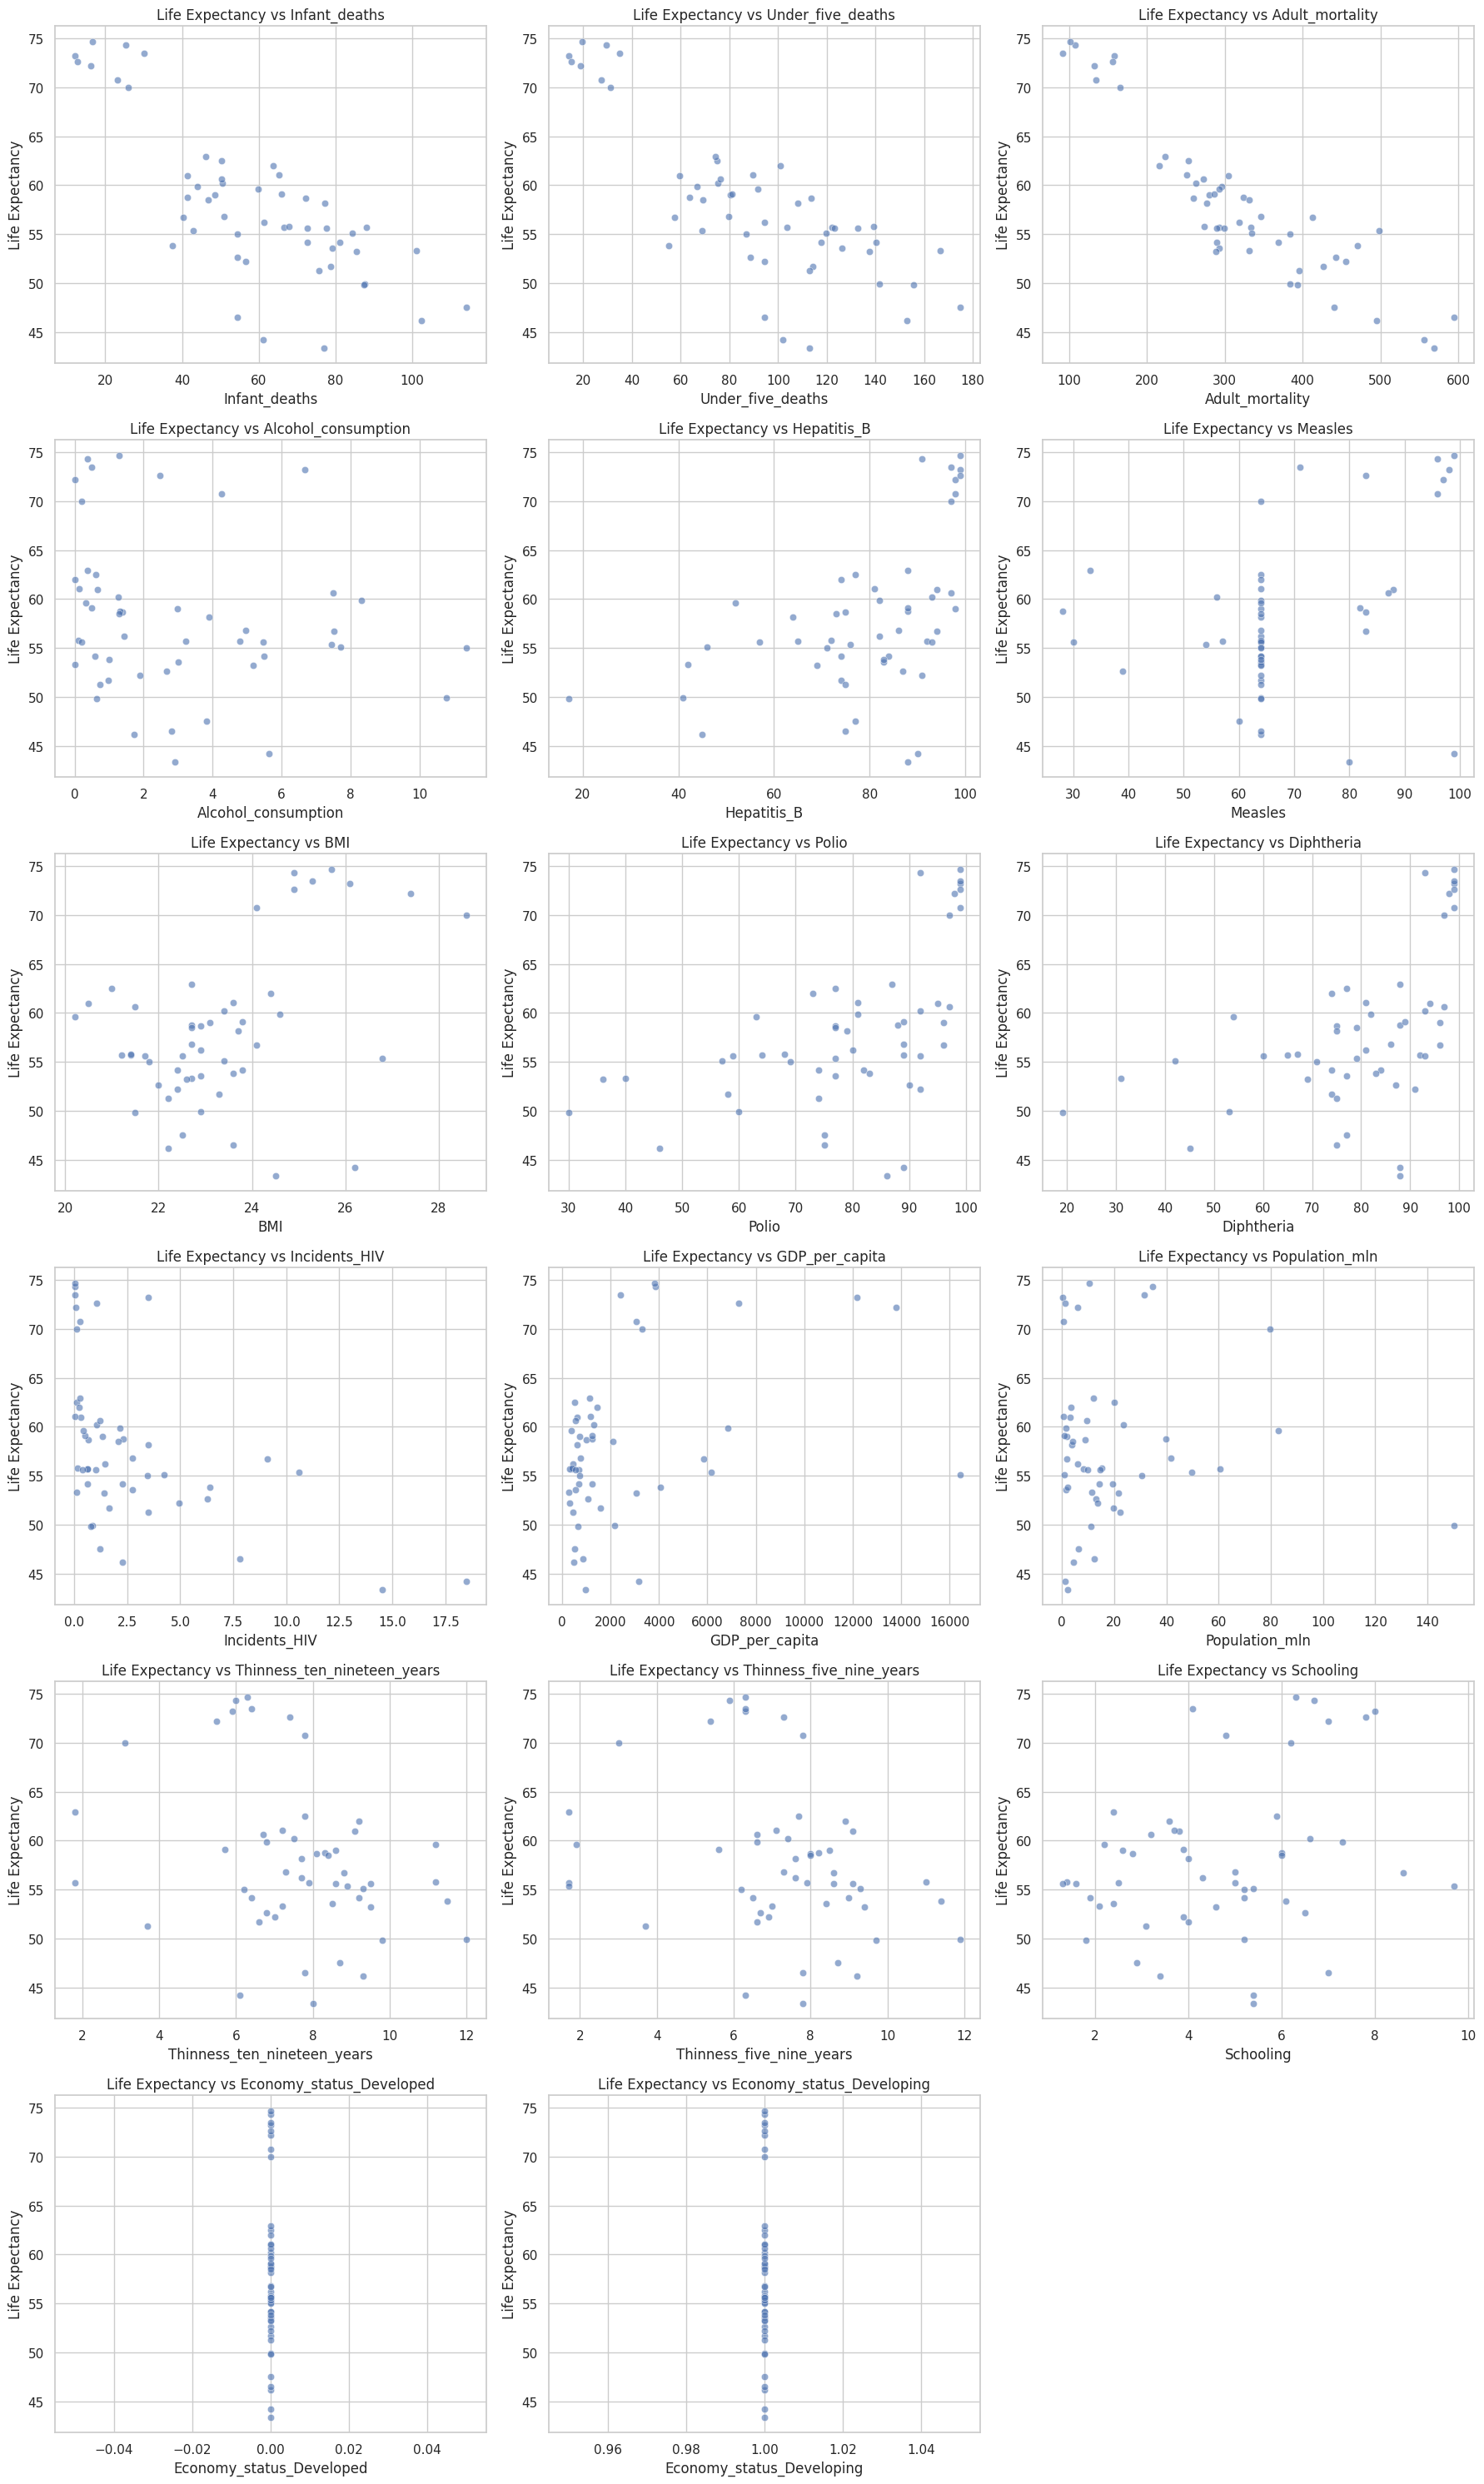

In [11]:
# Set up Seaborn theme
sns.set_theme(style="whitegrid")

# Identify numerical columns excluding 'Life_expectancy'
numerical_cols = subset.select_dtypes(include='number').columns.tolist()
numerical_cols.remove('Life_expectancy')
numerical_cols.remove('Year')

# Create scatter plots of Life_expectancy vs each numerical variable
num_plots = len(numerical_cols)
cols = 3
rows = (num_plots // cols) + int(num_plots % cols != 0)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.scatterplot(data=subset, x=col, y='Life_expectancy', ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Life Expectancy vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Life Expectancy')

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Identification and description of the patterns that emerge, highlighting any variables that exhibit a particularly strong or consistent relationship with life expectancy

The scatter plots show that life expectancy is strongly and negatively related to variables like infant deaths, under-five deaths, adult mortality, and incidents of HIV. This means that countries with high death rates and more HIV cases tend to have lower life expectancy.

On the other hand, variables like BMI, GDP per capita, schooling, and vaccination rates (Polio, Diphtheria, Hepatitis B) show a positive relationship.This suggests that countries with better health, education, and income levels generally have longer life expectancy.

Interestingly, measles, alcohol consumption, and population size show weaker or more scattered patterns, suggesting either complex or non-linear relationships.

The binary variables for economy status show no variation, likely due to data limitations or country-level classification homogeneity.

**Summary of key relationships**

---


**Strong negative**: Infant deaths, under-five deaths, adult mortality, HIV.

**Strong positive**: Schooling, GDP per capita, BMI, vaccines.

**Weak or unclear**: Alcohol, measles, population.


    
These patterns suggest that improving basic health, education, and economic conditions can significantly raise life expectancy across African countries.


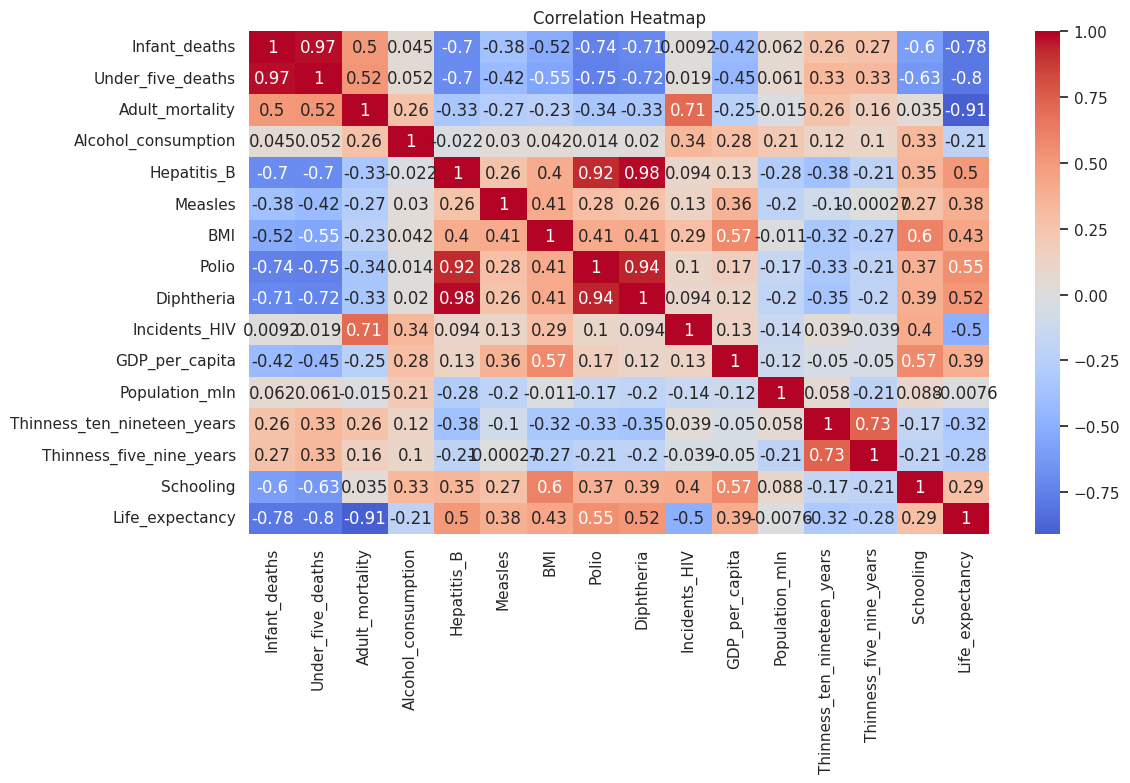

In [12]:
plt.figure(figsize=(12, 8))

corr = subset[numerical_cols + ['Life_expectancy']].drop(columns=['Economy_status_Developed', 'Economy_status_Developing']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


From the heatmap, Infant_deaths, Under_five_deaths, and Adult_mortality are highly positively correlated with each other (above 0.8).

This suggests potential multicollinearity.


Polio, Diphtheria, and Hepatitis_B are also strongly correlated (above 0.7), indicating they may overlap in information (all are vaccine-related).

GDP_per_capita, Schooling, and BMI show moderate correlations with each other (~0.3–0.6).

#### Testing for multicollinearity using Variance Inflation Factor (VIF)

### 1.3 Variable Selection, Actionability, and Statistical Considerations

---
Based on your exploratory data analysis, identify the variables you propose to include in your Bayesian linear model for inferring the effects of health indicators on life expectancy. In your discussion, please address both statistical and practical aspects by considering the following questions:


Your answer should integrate these considerations to justify a well-rounded and contextually informed model specification.

In [13]:
# Select only numeric variables excluding 'Life_expectancy'
X = subset.select_dtypes(include='number').drop(columns=['Life_expectancy'])

X = X.drop(columns=['Year'], errors='ignore')

# Add constant term for intercept
X = add_constant(X)

# Create DataFrame with VIF values
vif_df = pd.DataFrame()
vif_df['Variable'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIF table
print(vif_df)


                       Variable         VIF
0                 Infant_deaths   29.110134
1             Under_five_deaths   42.764294
2               Adult_mortality    6.686422
3           Alcohol_consumption    1.939027
4                   Hepatitis_B   47.754616
5                       Measles    1.700411
6                           BMI    3.021480
7                         Polio   10.154012
8                    Diphtheria   57.011491
9                 Incidents_HIV    5.440450
10               GDP_per_capita    3.077400
11               Population_mln    2.043107
12  Thinness_ten_nineteen_years    3.129804
13     Thinness_five_nine_years    3.134044
14                    Schooling    4.864473
15     Economy_status_Developed         NaN
16    Economy_status_Developing  799.447022


/usr/local/lib/python3.11/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


The Variance Inflation Factor (VIF) values above 10, such as for Infant_deaths, Under_five_deaths, and Hepatitis_B, indicate potential multicollinearity issues between predictors. This suggests that these variables may be highly correlated with each other, which could affect the stability of the regression coefficients.

In [14]:
# Extract correlations with Life_expectancy
life_corr = corr['Life_expectancy'].drop('Life_expectancy')

# Define score labels
def actionability_level(c):
    if abs(c) >= 0.5:
        return 'High (3)'
    elif abs(c) >= 0.25:
        return 'Medium (2)'
    else:
        return 'Low (1)'

# Create DataFrame with scores
actionability_df = pd.DataFrame({
    'Variable': life_corr.index,
    'Correlation with life expectancy': life_corr.values,
    'Actionability': life_corr.apply(actionability_level)
}).sort_values(by='Actionability', ascending=True)

# Show result
actionability_df


,Variable,Correlation with life expectancy,Actionability
Infant_deaths,Infant_deaths,-0.782933,High (3)
Under_five_deaths,Under_five_deaths,-0.803898,High (3)
Adult_mortality,Adult_mortality,-0.909129,High (3)
Hepatitis_B,Hepatitis_B,0.502030,High (3)
Polio,Polio,0.547000,High (3)
Diphtheria,Diphtheria,0.515040,High (3)
Incidents_HIV,Incidents_HIV,-0.500053,High (3)
Alcohol_consumption,Alcohol_consumption,-0.208726,Low (1)
Population_mln,Population_mln,-0.007611,Low (1)
Measles,Measles,0.382173,Medium (2)


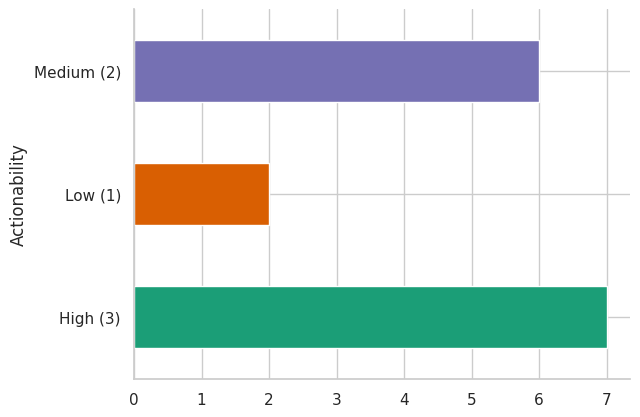

In [15]:
# @title Actionability

from matplotlib import pyplot as plt
import seaborn as sns
actionability_df.groupby('Actionability').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

#### Which variables appear most influential and relevant according to your analyses, and what underlying mechanisms might justify their inclusion?





| **Variable**                        | **Type**              | **Correlation with Life Expectancy** | **Justification / Underlying Mechanism** |
|------------------------------------|-----------------------|--------------------------------------|-------------------------------------------|
| Adult_mortality                    | Health-related        | Strong negative (−0.91)              | High adult mortality indicates poor healthcare access and a high disease burden, which directly reduces average life expectancy. |
| Under_five_deaths / Infant_deaths | Health-related        | Strong negative (−0.80 / −0.78)      | These variables reflect the quality of maternal and child healthcare; elevated values signal inadequate healthcare systems and increased early-life mortality. |
| Incidents_HIV                      | Health-related        | Moderate negative (−0.50)            | A high incidence of HIV increases mortality risk, particularly in regions with limited access to treatment, thus lowering overall life expectancy. |
| BMI                                | Health/nutritional    | Moderate positive (+0.43)            | A balanced BMI is an indicator of good nutritional status, while very low BMI can signal undernutrition and poverty, both of which negatively affect life expectancy. |
| **Vaccination Coverage (Diphtheria, Polio, Hepatitis B)** | Health-related | Moderate positive (~+0.50)           | Higher immunization rates protect against preventable diseases, reducing childhood illness and death and improving population-level health outcomes. |


#### Reflect on the concept of actionability: To what extent can interventions realistically improve these variables? Consider whether a variable represents a direct target for policy change (for example, immunization rates) versus a more distal or structural factor (such as overall GDP per capita).



#### Reflection on Actionability

| **Variable**                | **Actionability** | **Comment** |
|-----------------------------|-------------------|-------------|
| **Adult_mortality**         | High       | Can be improved through targeted health interventions (such as, access to primary care, screening, treatment), though outcomes depend on system-wide health investments. |
| **Under_five / Infant_deaths** | High          | Highly actionable with existing interventions (such as, improved prenatal care, skilled birth attendance, vaccinations, nutrition programs). |
| **GDP_per_capita**          | Low               | Structural and influenced by long-term economic policy, political stability, and international trade—difficult to change in the short term. |
| **Schooling**               | Medium            | Can be improved through educational policies, but effects on life expectancy are indirect and seen over a longer time horizon. |
| **Incidents_HIV**           | High              | Highly actionable through public health campaigns, access to antiretrovirals (ARVs), prevention education, and testing programs. |
| **BMI**                     | Medium            | Influenced by nutrition and food security, which can be addressed via agricultural and poverty-reduction programs, though change is gradual. |

#### How do potential issues like multicollinearity influence your variable selection? Discuss whether highly correlated variables should be combined, represented by a single measure, or treated separately, and explain your reasoning.




Multicollinearity affects variable selection by making it hard to separate the effects of predictors. In the correlation map,

Under_five_deaths captures Infant_deaths(r = 0.97): they both measure similar early child mortality so  Infant_deaths should be dropped.

Diphtheria, Polio, and Hepatitis_B (r > 0.9): all reflect immunization — best combined into one vaccine index.


In summary:

Combine if variables are highly correlated and conceptually similar.

Keep separate if they measure distinct constructs.
This avoids redundancy and improves model interpretability.

In [16]:
# Recreate the subset from 2008
subset = africa[africa['Year'] == 2008].copy()

# Combine vaccination indicators
subset['Vaccination_Coverage'] = subset[['Diphtheria', 'Hepatitis_B', 'Polio']].mean(axis=1)

# Drop highly collinear original variables
subset = subset.drop(columns=[
    'Infant_deaths',
    'Diphtheria', 'Hepatitis_B', 'Polio',
    'Economy_status_Developing'
])

# Select final variables
selected_columns = [ 'Life_expectancy',
    'Adult_mortality','BMI', 'Incidents_HIV', 'Under_five_deaths',
    'Vaccination_Coverage'
]

# Final cleaned dataset for modeling
cleaned_subset = subset[selected_columns].reset_index(drop=True)



In [17]:
cleaned_subset

,Life_expectancy,Adult_mortality,BMI,Incidents_HIV,Under_five_deaths,Vaccination_Coverage
0,56.2,318.7475,22.9,1.45,94.4,81.000000
1,53.3,331.4010,22.7,0.13,166.5,37.666667
2,58.7,259.3400,22.9,0.65,113.7,75.666667
3,56.8,345.9945,22.7,2.76,79.6,87.000000
4,55.7,292.7370,21.4,0.62,122.3,64.666667
5,46.2,494.9685,22.2,2.28,152.8,45.333333
6,43.4,569.1065,24.5,14.53,113.0,87.333333
7,52.6,442.7350,22.0,6.29,88.7,88.000000
8,54.2,289.5660,22.4,0.62,140.2,74.000000
9,46.5,594.7345,23.6,7.81,94.5,75.000000


## 2. Bayesian Linear Regression

Subset the data to 2008 and the variables you have chosen based on your EDA and reasoning. Implement a Bayesian linear regression model to infer the effects of the chosen health indicators on life expectancy.



### 2.1 Mathematical Expression of the Model
Write down the mathematical expression of the model.

 #### Mathematical expression of the model

 Bayesian linear regression model for life expectancy as follows,

#### Data Model:
Given a dataset of $N$ observations and $K$ predictors (independent variables), we have the following:

1. **Predictor matrix $X$**: A matrix of size $N \times K$ where each row corresponds to an observation, and each column corresponds to a predictor.

2. **Outcome vector $y$**: A vector of length $N$ representing the life expectancy (dependent variable) corresponding to each observation.

#### Model Formula:
The relationship between the predictors and the outcome is modeled linearly as:

$$
y_i = \beta_0 + \sum_{k=1}^{K} \beta_k X_{ik} + \epsilon_i \quad \text{for } i = 1, 2, \dots, N
$$

Where:
- $y_i$ is the life expectancy for observation $i$.
- $\beta_0$ is the intercept (the baseline life expectancy when all predictors are zero).
- $\beta_k$ is the regression coefficient for predictor $k$.
- $X_{ik}$ is the value of predictor $k$ for observation $i$.
- $\epsilon_i$ is the residual error for observation $i$, assumed to be normally distributed with mean 0 and standard deviation $\sigma$.

#### Priors:
- The intercept $\beta_0$ is given a normal prior:  
  $$ \beta_0 \sim \mathcal{N}(60, 10) $$  
  (Mean of 60, standard deviation of 10)
  
- The regression coefficients $\beta_k$ are given a normal prior:  
  $$ \beta_k \sim \mathcal{N}(0, 10) $$  
  (Mean of 0, standard deviation of 10)

- The residual standard deviation $\sigma$ follows a Cauchy distribution:  
  $$ \sigma \sim \text{Cauchy}(0, 5) $$  
  (Centered at 0, with scale 5)

#### Likelihood:
The likelihood function for the data given the model is:

$$
y_i \sim \mathcal{N}(\mu_i, \sigma) \quad \text{for } i = 1, 2, \dots, N
$$

Where:
- $\mu_i = \beta_0 + \sum_{k=1}^{K} \beta_k X_{ik}$ is the linear predictor for observation $i$.

#### Generated Quantities:
1. **Log-likelihood ($\text{log\_lik}$)**: This is the log probability of observing the data given the model parameters:
   $$ \log p(y_i | \mu_i, \sigma) = \log \mathcal{N}(y_i | \mu_i, \sigma) $$

2. **Posterior predictive samples ($y_{\text{rep}}$)**: For each observation $i$, we generate a posterior predictive sample:
   $$ y_{\text{rep}} \sim \mathcal{N}(\mu_i, \sigma) $$

A simple Bayesian linear regression model in Stan with specified priors, likelihood, and posterior predictive sampling.




### 2.2 Implement the Model in Stan and infer the posterior using MCMC
Implement the Bayesian linear regression model in Stan. Compile the model and sample from the posterior using MCMC.
You will not be judged on the efficiency of the Stan code, but rather on the correctness of the model implementation.

In [18]:
#  Stan model
stan_code = """
data {
    int<lower=1> N;                // number of observations
    int<lower=1> K;                // number of predictors
    matrix[N, K] X;                // predictor matrix
    vector[N] y;                   // life expectancy (outcome variable)
}

parameters {
    real beta0;                    // intercept
    vector[K] beta;                 // regression coefficients
    real<lower=0> sigma;           // residual error
}

transformed parameters {
    vector[N] mu;
    mu = beta0 + X * beta;         // linear model
}

model {
    beta0 ~ normal(60, 10);          // prior for intercept
    beta ~ normal(0, 10);           // prior for coefficients
    sigma ~ cauchy(0, 5);          // prior for residual standard deviation
    y ~ normal(mu, sigma);         // likelihood
}

generated quantities {
    vector[N] log_lik;             // log-likelihood for each data point
    array[N] real y_rep;           // posterior predictive values

    for (i in 1:N) {
        log_lik[i] = normal_lpdf(y[i] | mu[i], sigma);
        y_rep[i] = normal_rng(mu[i], sigma); // posterior predictive
    }
}
"""

#model1_filename = output_dir.joinpath("health_model.stan")

with open("bayes_lm.stan", "w") as f:
    f.write(stan_code)


In [19]:
# Prepare X and y
X = cleaned_subset.drop(columns='Life_expectancy').values  # shape: (N, 5)
y = cleaned_subset['Life_expectancy'].values               # shape: (N,)

# Get dimensions
N, K = X.shape

# Stan data dictionary
stan_data = {
    'N': N,
    'K': K,
    'X': X,
    'y': y
}


In [20]:
# Compile Stan model
model = CmdStanModel(stan_file='bayes_lm.stan')


DEBUG:cmdstanpy:Removing /content/bayes_lm
14:12:28 - cmdstanpy - INFO - compiling stan file /content/bayes_lm.stan to exe file /content/bayes_lm
INFO:cmdstanpy:compiling stan file /content/bayes_lm.stan to exe file /content/bayes_lm
DEBUG:cmdstanpy:cmd: make STANCFLAGS+=--filename-in-msg=bayes_lm.stan /content/bayes_lm
cwd: cmdstan-2.36.0
DEBUG:cmdstanpy:Console output:

--- Compiling pre-compiled header. This might take a few seconds. ---
g++ -std=c++17 -pthread -D_REENTRANT -Wno-sign-compare -Wno-ignored-attributes -Wno-class-memaccess      -I stan/lib/stan_math/lib/tbb_2020.3/include    -O3 -I src -I stan/src -I stan/lib/rapidjson_1.1.0/ -I lib/CLI11-1.9.1/ -I stan/lib/stan_math/ -I stan/lib/stan_math/lib/eigen_3.4.0 -I stan/lib/stan_math/lib/boost_1.84.0 -I stan/lib/stan_math/lib/sundials_6.1.1/include -I stan/lib/stan_math/lib/sundials_6.1.1/src/sundials    -DBOOST_DISABLE_ASSERTS          -c stan/src/stan/model/model_header.hpp -o stan/src/stan/model/model_header.hpp.gch/model_h

In [21]:
fit = model.sample(data=stan_data, chains=4, iter_sampling=2000, iter_warmup=1000, seed=123)

DEBUG:cmdstanpy:cmd: /content/bayes_lm info
cwd: None
DEBUG:cmdstanpy:input tempfile: /tmp/tmpysycxro_/1d311w2s.json
14:13:42 - cmdstanpy - INFO - CmdStan start processing
INFO:cmdstanpy:CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:idx 1
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/content/bayes_lm', 'id=1', 'random', 'seed=123', 'data', 'file=/tmp/tmpysycxro_/1d311w2s.json', 'output', 'file=/tmp/tmpysycxro_/bayes_lm2r9iev5j/bayes_lm-20250330141342_1.csv', 'method=sample', 'num_samples=2000', 'num_warmup=1000', 'algorithm=hmc', 'adapt', 'engaged=1']
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/content/bayes_lm', 'id=2', 'random', 'seed=123', 'data', 'file=/tmp/tmpysycxro_/1d311w2s.json', 'output', 'file=/tmp/tmpysycxro_/bayes_lm2r9iev5j/bayes_lm-20250330141342_2.csv', 'method=sample', 'num_samples=2000', 'num_warmup=1000', 'algorithm=hmc', 'adapt', 'engaged=1']
DEBUG:cmdstanpy:idx 2
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/content/bayes_lm', 'id=3', 'random', 'seed=123', 'data', 'file=/tmp/tmpysycxro_/1d311w2s.json', 'output', 'file=/tmp/tmpysycxro_/bayes_lm2r9iev5j

14:13:49 - cmdstanpy - INFO - CmdStan done processing.
INFO:cmdstanpy:CmdStan done processing.
DEBUG:cmdstanpy:runset
RunSet: chains=4, chain_ids=[1, 2, 3, 4], num_processes=4
 cmd (chain 1):
	['/content/bayes_lm', 'id=1', 'random', 'seed=123', 'data', 'file=/tmp/tmpysycxro_/1d311w2s.json', 'output', 'file=/tmp/tmpysycxro_/bayes_lm2r9iev5j/bayes_lm-20250330141342_1.csv', 'method=sample', 'num_samples=2000', 'num_warmup=1000', 'algorithm=hmc', 'adapt', 'engaged=1']
 retcodes=[0, 0, 0, 0]
 per-chain output files (showing chain 1 only):
 csv_file:
	/tmp/tmpysycxro_/bayes_lm2r9iev5j/bayes_lm-20250330141342_1.csv
 console_msgs (if any):
	/tmp/tmpysycxro_/bayes_lm2r9iev5j/bayes_lm-20250330141342_0-stdout.txt
DEBUG:cmdstanpy:Chain 1 console:
method = sample (Default)
  sample
    num_samples = 2000
    num_warmup = 1000 (Default)
    save_warmup = false (Default)
    thin = 1 (Default)
    adapt
      engaged = true (Default)
      gamma = 0.05 (Default)
      delta = 0.8 (Default)
      kapp

### 2.3 Diagnose the Model

Conduct model diagnostics to ensure that the sampler did not encounter any issues during the sampling process. Check for convergence, effective sample size, and goodness of fit.

In [22]:
print(fit.diagnose())

DEBUG:cmdstanpy:cmd: cmdstan-2.36.0/bin/diagnose /tmp/tmpysycxro_/bayes_lm2r9iev5j/bayes_lm-20250330141342_1.csv /tmp/tmpysycxro_/bayes_lm2r9iev5j/bayes_lm-20250330141342_2.csv /tmp/tmpysycxro_/bayes_lm2r9iev5j/bayes_lm-20250330141342_3.csv /tmp/tmpysycxro_/bayes_lm2r9iev5j/bayes_lm-20250330141342_4.csv
cwd: None


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [23]:
posterior=az.from_cmdstanpy(posterior=fit)
print(az.summary(posterior, var_names=['beta0', 'sigma', 'beta'], hdi_prob=0.95)["r_hat"])

beta0      1.0
sigma      1.0
beta[0]    1.0
beta[1]    1.0
beta[2]    1.0
beta[3]    1.0
beta[4]    1.0
Name: r_hat, dtype: float64


✔ Convergence:

All $\hat{R}$ (R-hat) values are ≈ 1.00, indicating that all chains have converged.

In [24]:
print(az.summary(posterior, var_names=['beta0', 'sigma', 'beta'], hdi_prob=0.95)["ess_bulk"])

beta0      2914.0
sigma      5662.0
beta[0]    4318.0
beta[1]    3267.0
beta[2]    3848.0
beta[3]    4604.0
beta[4]    4488.0
Name: ess_bulk, dtype: float64




✔ Effective Sample Size (ESS):

All ESS_bulk and ESS_tail values are well above 1000, indicating good sampling efficiency and reliable posterior estimates.





✔ No divergences or treedepth issues:

The output of fit.diagnose() confirms:
  Tree depth is sufficient

  No divergent transitions

  E-BFMI is satisfactory
  
  No warnings raise

#### Trace Plots and Posterior Predictive Checks

### 2.4 Summarize and Visualise the Results

In [25]:
idata = az.from_cmdstanpy(posterior=fit)
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats

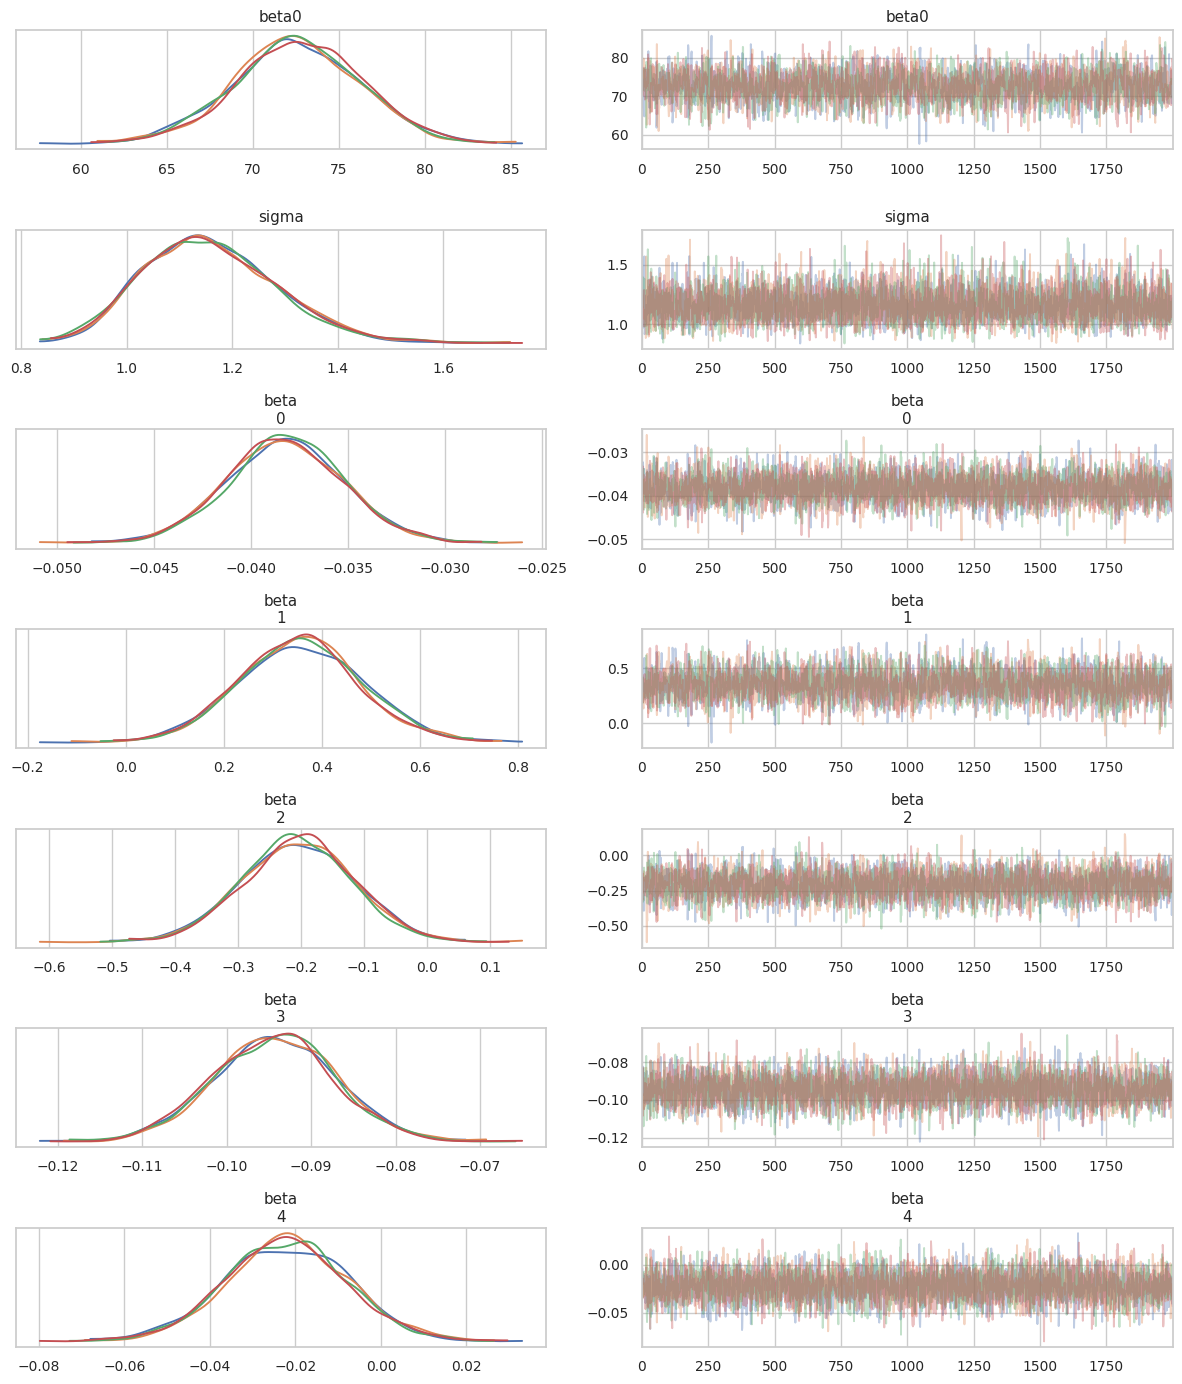

In [26]:
az.plot_trace(idata, var_names=['beta0', 'sigma', 'beta'], compact=False, combined=False)
plt.tight_layout()
plt.show()

The plots show the posterior distributions and trace plots for the model parameters ($\beta_0$, $\sigma$, and the $\beta$ coefficients), indicating the convergence of the chains and providing insight into the uncertainty and variability of the parameter estimates for life expectancy based on the selected health indicators.

Trace plots show well-mixed chains with no signs of divergence or stickiness.

In [27]:
fit.summary().loc[['beta0', 'sigma'] + [f'beta[{i+1}]' for i in range(X.shape[1])]]

DEBUG:cmdstanpy:cmd: cmdstan-2.36.0/bin/stansummary --percentiles= 5,50,95 --sig_figs=6 --csv_filename=/tmp/tmpysycxro_/stansummary-bayes_lm-33r14wlu.csv /tmp/tmpysycxro_/bayes_lm2r9iev5j/bayes_lm-20250330141342_1.csv /tmp/tmpysycxro_/bayes_lm2r9iev5j/bayes_lm-20250330141342_2.csv /tmp/tmpysycxro_/bayes_lm2r9iev5j/bayes_lm-20250330141342_3.csv /tmp/tmpysycxro_/bayes_lm2r9iev5j/bayes_lm-20250330141342_4.csv
cwd: None


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
beta0,72.601900,0.068779,3.707010,3.612430,66.329500,72.545400,78.680600,2914.36,3573.38,1.00018
sigma,1.159850,0.001729,0.128513,0.126088,0.970157,1.149350,1.383610,5661.64,4950.83,1.00053
beta[1],-0.038225,0.000046,0.003030,0.002951,-0.043162,-0.038243,-0.033261,4318.49,5138.11,1.00032
beta[2],0.354974,0.002198,0.125261,0.123159,0.151295,0.355306,0.565178,3266.91,4063.96,1.00052
beta[3],-0.205269,0.001434,0.088828,0.087578,-0.351142,-0.204924,-0.060708,3847.83,4578.66,1.00065
beta[4],-0.094310,0.000107,0.007219,0.007151,-0.106180,-0.094277,-0.082443,4603.77,5116.95,1.00023
beta[5],-0.022044,0.000214,0.014294,0.014110,-0.045415,-0.022074,0.001426,4487.53,4939.33,1.00128


Summarise the posterior distribution of the model parameters and provide point estimates and 95% credible intervals for the effects of the chosen health indicators on life expectancy.

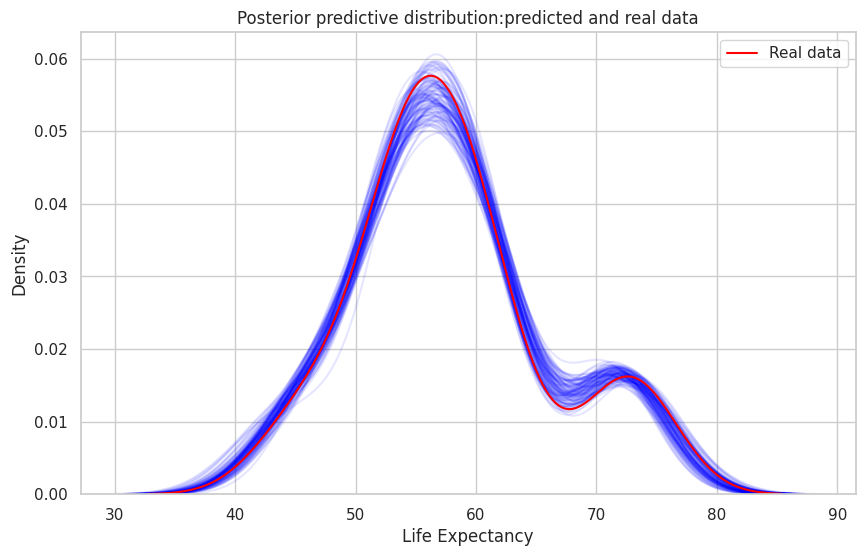

In [28]:
y_hat= fit.stan_variable('y_rep')
y_real = cleaned_subset.Life_expectancy.values

plt.figure(figsize=(10, 6))
for i in range(100):
    sns.kdeplot(y_hat[i],color='blue',alpha=0.1)
sns.kdeplot(y_real,color='red',label="Real data")
plt.xlabel("Life Expectancy")
plt.ylabel("Density")
plt.title("Posterior predictive distribution:predicted and real data")
plt.legend()
plt.show()

The plot shows that the model's predicted distribution closely matches the real data, indicating a good fit between the predicted and observed life expectancy values.

### 2.6 Interpret the Results

In [29]:
new_data_dict = {
    'Adult_mortality': 263.6,
    'Alcohol_consumption': 3.0,
    'BMI': 23.8,
    'Diphtheria': 80.9,
    'Economy_status_Developed': 0.0,
    'Economy_status_Developing': 1.0,
    'GDP_per_capita': 2705,
    'Hepatitis_B': 81.5,
    'Incidents_HIV': 1.8,
    'Infant_deaths': 47.6,
    'Measles': 69.5,
    'Polio': 81.1,
    'Population_mln': 22.1,
    'Schooling': 5.3,
    'Thinness_five_nine_years': 6.6,
    'Thinness_ten_nineteen_years': 6.7,
    'Under_five_deaths': 68.8
}

In [30]:
selected_columns2 = [ 'Adult_mortality','BMI', 'Incidents_HIV', 'Under_five_deaths']
new_data = pd.DataFrame([new_data_dict])[selected_columns2]
new_data2 = pd.DataFrame([new_data_dict])

In [31]:
new_data['Vaccination_Coverage'] = new_data2[['Diphtheria', 'Hepatitis_B', 'Polio']].mean(axis=1)

In [32]:
new_data

,Adult_mortality,BMI,Incidents_HIV,Under_five_deaths,Vaccination_Coverage
0,263.6,23.8,1.8,68.8,81.166667


In [33]:
beta0 = fit.stan_variable('beta0').mean()
beta = fit.stan_variable('beta').mean(axis=0)
life_exp_pred = beta0 + np.dot(beta, new_data.values[0])
print(f"Predicted Life Expectancy: {life_exp_pred:.2f} years")
# Iterate over the columns present in new_data
for i, var in enumerate(new_data.columns):
    new_data_mod = new_data.copy()
    change = 0.1 if beta[i] > 0 else -0.1
    new_data_mod[var] *= (1 + change)
    pred_mod = beta0 + np.dot(beta, new_data_mod.values[0])
    print(f"{var} {('+10%' if beta[i] > 0 else '-10%')}: {pred_mod:.2f} years")

Predicted Life Expectancy: 62.33 years
Adult_mortality -10%: 63.33 years
BMI +10%: 63.17 years
Incidents_HIV -10%: 62.36 years
Under_five_deaths -10%: 62.98 years
Vaccination_Coverage -10%: 62.51 years


### Interpretation of Bayesian Linear Regression Model Results

From the output, the predicted life expectancy based on the current values of the health indicators is 62.33 years. How 10% changes in each health indicator affect life expectancy.

**Adult Mortality (-10% change)**

After a 10% reduction in Adult Mortality, life expectancy increases to 63.33 years.

This indicates that a decrease in Adult Mortality positively impacts life expectancy, as expected. Higher mortality rates typically lead to lower life expectancy, so reducing adult mortality will have a favorable impact on increasing life expectancy.

**BMI (+10% change)**

Increasing BMI by 10% leads to a slight increase in life expectancy to 63.17 years.

Although the effect is positive, the change is relatively small. A higher BMI (especially within healthy ranges) is generally linked to better health outcomes, though the impact may vary based on the context.

**Incidents of HIV (-10% change)**

Reducing HIV incidents by 10% results in a small increase in life expectancy to 62.36 years.

This is also a positive impact. Reducing the spread of HIV through interventions such as education and healthcare access could improve life expectancy by lowering the number of people suffering from HIV/AIDS, which affects overall health and longevity.

**Under Five Deaths (-10% change)**

Reducing under-five deaths by 10% leads to an increase in life expectancy to 62.98 years.

Decreasing child mortality is a well-known way to increase life expectancy, as it reduces the number of deaths in the younger population, which has a significant effect on life expectancy in a country or region.

**Vaccination Coverage (-10% change)**

A 10% reduction in vaccination coverage results in a decrease in life expectancy to 62.51 years.

This is a negative impact, as lower vaccination rates generally correlate with higher morbidity and mortality from preventable diseases. Vaccination coverage is crucial to reducing the burden of infectious diseases and improving life expectancy.



Based on the analysis, here are some key recommendations.

**Focus on Adult Mortality**

Reducing adult mortality should be prioritized, as it has the largest positive effect on life expectancy among the indicators tested. Policies to improve healthcare access, reduce preventable diseases, and encourage healthier lifestyles could help achieve this.

**Improve Vaccination Coverage**

Increasing vaccination coverage should also be a priority. The results show that reducing vaccination coverage leads to a decrease in life expectancy, highlighting the importance of vaccination in reducing disease burden and improving overall health.

**Monitor Child Mortality (Under Five Deaths)**

Efforts to reduce under-five deaths have a significant positive effect on life expectancy. Investing in child health, such as improving access to healthcare and sanitation, could result in substantial improvements.

**HIV Prevention Programs**

Reducing HIV incidents is also important, though its impact is somewhat smaller than other factors. Programs that focus on HIV prevention, education, and treatment can have a positive impact on overall public health and life expectancy.

**Limited Effect of BMI**

While improving BMI has a positive effect, the magnitude of this effect is smaller compared to other factors. However, promoting healthier diets and physical activity could have long-term health benefits.

**Potential Benefits of Focusing on These Indicators**
Improving health outcomes in these areas will lead to reduced healthcare costs, as fewer people would need to seek treatment for preventable diseases.

**Increased productivity**
 A healthier population contributes more effectively to the economy.

Improved quality of life for the population, which is crucial for social and economic development.

By focusing on these key health indicators, the government can make substantial progress toward increasing life expectancy in the region, even with a limited budget.

## Extending the linear model

Filtering and preparing the africa dataset by selecting relevant columns.

Calculating the mean vaccine coverage

Filtering by selected countries

Creating a categorical index for each country

Output the cleaned and transformed dataset.

In [34]:
africa_subset = africa[['Country', 'Year', 'Adult_mortality', 'BMI',
                                'Incidents_HIV', 'Under_five_deaths', 'Polio', 'Diphtheria', 'Hepatitis_B', 'Life_expectancy']].sort_values(
    by=['Country', 'Year']).reset_index(drop=True)

africa_subset['Mean_vaccine_coverage'] = africa_subset[['Polio', 'Diphtheria', 'Hepatitis_B']].mean(axis=1)

# Filter to include only the countries in your selected_countries list
africa_subset = africa_subset[africa_subset['Country'].isin(selected_countries)]

# Create an index for each country (as a categorical variable)
africa_subset['country_idx'] = africa_subset['Country'].astype('category').cat.codes + 1

africa_subset


,Country,Year,Adult_mortality,BMI,Incidents_HIV,Under_five_deaths,Polio,Diphtheria,Hepatitis_B,Life_expectancy,Mean_vaccine_coverage,country_idx
288,Eswatini,2000,559.1865,25.5,21.68,112.2,87,84,83,47.5,84.666667,1
289,Eswatini,2001,591.9355,25.6,20.80,115.8,87,84,86,45.8,85.666667,1
290,Eswatini,2002,624.6850,25.6,20.31,117.7,87,85,88,44.4,86.666667,1
291,Eswatini,2003,615.7080,25.7,20.22,119.2,87,85,90,43.4,87.333333,1
292,Eswatini,2004,606.7310,25.8,19.93,119.7,88,86,93,42.7,89.000000,1
293,Eswatini,2005,597.7545,25.9,19.87,119.4,88,86,95,42.5,89.666667,1
294,Eswatini,2006,588.7775,26.0,18.94,109.0,88,87,93,42.7,89.333333,1
295,Eswatini,2007,579.8010,26.1,18.67,103.8,88,87,92,43.3,89.000000,1
296,Eswatini,2008,555.8025,26.2,18.50,101.9,89,88,90,44.2,89.000000,1
297,Eswatini,2009,531.8035,26.3,17.36,96.0,89,88,88,45.3,88.333333,1


# New Stan Model to Include Year and Country Effects

### Model Overview:
This Bayesian linear regression model accounts for country-specific intercepts and year effects in predicting life expectancy based on multiple health indicators.

#### Model Formula:
The model for life expectancy $y_i$ is given by:

$$
y_i = \alpha_{\text{country}[i]}  + \sum_{k=1}^{K} \beta_k X_{ik} + \epsilon_i
$$

Where:

- $\alpha_{\text{country}[i]}$: Country-specific intercept for observation $i$
- $X_{ik}$: The $k$-th health indicator for observation $i$
- $\epsilon_i$: Residual error, assumed to follow a normal distribution with mean 0 and standard deviation $\sigma$

#### Prior Distributions:
We assign the following prior distributions:
- $\beta_k \sim \mathcal{N}(0, 10)$ for each regression coefficient
- $\alpha_j \sim \mathcal{N}(0, 5)$ for country-specific intercepts
- $\sigma \sim \text{Cauchy}(0, 5)$

#### Likelihood:
The likelihood function for each data point is:

$$
y_i \sim \mathcal{N}(\mu_i, \sigma)
$$

Where $\mu_i$ is given by the linear combination:

$$
\mu_i =  \alpha_{\text{country}[i]}  + X_i \times \beta
$$




In [64]:
from pathlib import Path

# Define an improved Stan model to include year and country effects
new_stan_code = """
data {
    int<lower=1> N;                      // Number of observations
    int<lower=1> K;                      // Number of predictors
    int<lower=1> J;                      // Number of countries
    array[N] int<lower=1, upper=J> country; // Country index
    matrix[N, K] X;                      // Predictor matrix
    vector[N] y;                         // Life expectancy
}

parameters {

    vector[K] beta;                      // Coefficients for health indicators
    vector[J] alpha;                    // Country-specific intercepts
    real<lower=0> sigma;                // Residual error
}

transformed parameters {
    vector[N] mu;
    for (i in 1:N) {
        mu[i] = alpha[country[i]] + X[i] * beta;
    }
}

model {
    // Priors

    beta ~ normal(0, 10);
    alpha ~ normal(0, 5);
    sigma ~ cauchy(0, 5);

    // Likelihood
    y ~ normal(mu, sigma);
}

generated quantities {
    vector[N] log_lik;
    vector[N] y_rep;
    for (i in 1:N) {
        log_lik[i] = normal_lpdf(y[i] | mu[i], sigma);
        y_rep[i] = normal_rng(mu[i], sigma);
    }
}
"""

# Save to file
with open("new_bayes_lm.stan", "w") as f:
     f.write(new_stan_code)

"Stan model written to new_bayes_lm.stan.stan"


'Stan model written to new_bayes_lm.stan.stan'

In [65]:
X = africa_subset[['Adult_mortality', 'BMI', 'Incidents_HIV', 'Under_five_deaths', 'Mean_vaccine_coverage']].values
year = africa_subset['Year'].values.astype(np.int64) # Ensure year is a NumPy array

# Outcome variable (life expectancy)
y = africa_subset['Life_expectancy'].values

country_idx = africa_subset['Country'].astype('category').cat.codes + 1

# Prepare data dictionary for Stan, including country index and year
new_stan_data = {
    'N': len(y),                           # Total number of observations
    'K': X.shape[1],                       # Number of predictors (columns in X)
    'J': len(np.unique(country_idx)),      # Number of countries (unique countries)
    'country': country_idx,                # Country index for each observation
    #'year': year,                          # Pass 'year' as a vector to Stan
    'X': X,                                # Predictor matrix (N x K)
    'y': y                                 # Life expectancy (response variable)
}

# Compile the Stan model
new_model = CmdStanModel(stan_file='new_bayes_lm.stan')

DEBUG:cmdstanpy:Removing /content/new_bayes_lm
14:45:48 - cmdstanpy - INFO - compiling stan file /content/new_bayes_lm.stan to exe file /content/new_bayes_lm
INFO:cmdstanpy:compiling stan file /content/new_bayes_lm.stan to exe file /content/new_bayes_lm
DEBUG:cmdstanpy:cmd: make STANCFLAGS+=--filename-in-msg=new_bayes_lm.stan /content/new_bayes_lm
cwd: cmdstan-2.36.0
DEBUG:cmdstanpy:Console output:

--- Translating Stan model to C++ code ---
bin/stanc --filename-in-msg=new_bayes_lm.stan --o=/content/new_bayes_lm.hpp /content/new_bayes_lm.stan

--- Compiling C++ code ---
g++ -std=c++17 -pthread -D_REENTRANT -Wno-sign-compare -Wno-ignored-attributes -Wno-class-memaccess      -I stan/lib/stan_math/lib/tbb_2020.3/include    -O3 -I src -I stan/src -I stan/lib/rapidjson_1.1.0/ -I lib/CLI11-1.9.1/ -I stan/lib/stan_math/ -I stan/lib/stan_math/lib/eigen_3.4.0 -I stan/lib/stan_math/lib/boost_1.84.0 -I stan/lib/stan_math/lib/sundials_6.1.1/include -I stan/lib/stan_math/lib/sundials_6.1.1/src/sund

In [66]:
# Fit the model
new_fit = new_model.sample(data = new_stan_data, chains=4, parallel_chains=4, iter_sampling=2000, iter_warmup=1000, seed=123)


DEBUG:cmdstanpy:cmd: /content/new_bayes_lm info
cwd: None
DEBUG:cmdstanpy:input tempfile: /tmp/tmpysycxro_/4j6b0a9r.json
14:46:08 - cmdstanpy - INFO - CmdStan start processing
INFO:cmdstanpy:CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/content/new_bayes_lm', 'id=1', 'random', 'seed=123', 'data', 'file=/tmp/tmpysycxro_/4j6b0a9r.json', 'output', 'file=/tmp/tmpysycxro_/new_bayes_lmvfy404lv/new_bayes_lm-20250330144608_1.csv', 'method=sample', 'num_samples=2000', 'num_warmup=1000', 'algorithm=hmc', 'adapt', 'engaged=1']
DEBUG:cmdstanpy:idx 1
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/content/new_bayes_lm', 'id=2', 'random', 'seed=123', 'data', 'file=/tmp/tmpysycxro_/4j6b0a9r.json', 'output', 'file=/tmp/tmpysycxro_/new_bayes_lmvfy404lv/new_bayes_lm-20250330144608_2.csv', 'method=sample', 'num_samples=2000', 'num_warmup=1000', 'algorithm=hmc', 'adapt', 'engaged=1']
DEBUG:cmdstanpy:idx 2
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/content/new_bayes_lm', 'id=3', 'random', 'seed=123', 'data', 'file=/tmp/tmpysycxro_/4j6b0a9r.json', 'output', 'file=/tmp/

14:46:22 - cmdstanpy - INFO - CmdStan done processing.
INFO:cmdstanpy:CmdStan done processing.
DEBUG:cmdstanpy:runset
RunSet: chains=4, chain_ids=[1, 2, 3, 4], num_processes=4
 cmd (chain 1):
	['/content/new_bayes_lm', 'id=1', 'random', 'seed=123', 'data', 'file=/tmp/tmpysycxro_/4j6b0a9r.json', 'output', 'file=/tmp/tmpysycxro_/new_bayes_lmvfy404lv/new_bayes_lm-20250330144608_1.csv', 'method=sample', 'num_samples=2000', 'num_warmup=1000', 'algorithm=hmc', 'adapt', 'engaged=1']
 retcodes=[0, 0, 0, 0]
 per-chain output files (showing chain 1 only):
 csv_file:
	/tmp/tmpysycxro_/new_bayes_lmvfy404lv/new_bayes_lm-20250330144608_1.csv
 console_msgs (if any):
	/tmp/tmpysycxro_/new_bayes_lmvfy404lv/new_bayes_lm-20250330144608_0-stdout.txt
DEBUG:cmdstanpy:Chain 1 console:
method = sample (Default)
  sample
    num_samples = 2000
    num_warmup = 1000 (Default)
    save_warmup = false (Default)
    thin = 1 (Default)
    adapt
      engaged = true (Default)
      gamma = 0.05 (Default)
      delt

In [67]:
print(new_fit.diagnose())

DEBUG:cmdstanpy:cmd: cmdstan-2.36.0/bin/diagnose /tmp/tmpysycxro_/new_bayes_lmvfy404lv/new_bayes_lm-20250330144608_1.csv /tmp/tmpysycxro_/new_bayes_lmvfy404lv/new_bayes_lm-20250330144608_2.csv /tmp/tmpysycxro_/new_bayes_lmvfy404lv/new_bayes_lm-20250330144608_3.csv /tmp/tmpysycxro_/new_bayes_lmvfy404lv/new_bayes_lm-20250330144608_4.csv
cwd: None


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



This means that the model has converged efficiently,

In [68]:
# Extract the results
new_fit_summary = new_fit.summary()

# Print the summary of the
new_fit_summary

DEBUG:cmdstanpy:cmd: cmdstan-2.36.0/bin/stansummary --percentiles= 5,50,95 --sig_figs=6 --csv_filename=/tmp/tmpysycxro_/stansummary-new_bayes_lm-9glarfqw.csv /tmp/tmpysycxro_/new_bayes_lmvfy404lv/new_bayes_lm-20250330144608_1.csv /tmp/tmpysycxro_/new_bayes_lmvfy404lv/new_bayes_lm-20250330144608_2.csv /tmp/tmpysycxro_/new_bayes_lmvfy404lv/new_bayes_lm-20250330144608_3.csv /tmp/tmpysycxro_/new_bayes_lmvfy404lv/new_bayes_lm-20250330144608_4.csv
cwd: None


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
lp__,-36.923500,0.046169,2.323560,2.163630,-41.357900,-36.556200,-33.831900,2646.38,3803.22,1.002990
beta[1],-0.047889,0.000091,0.005790,0.005807,-0.057287,-0.047974,-0.038233,4044.28,4637.86,1.000910
beta[2],2.661590,0.003523,0.199992,0.201033,2.323700,2.664650,2.986480,3231.26,3576.45,1.000440
beta[3],0.669339,0.003222,0.212528,0.215331,0.314307,0.674854,1.006800,4404.01,3976.92,1.002470
beta[4],-0.048531,0.000330,0.021726,0.021364,-0.083576,-0.048592,-0.012343,4410.99,4333.12,1.001340
...,...,...,...,...,...,...,...,...,...,...
y_rep[44],53.563300,0.014893,1.345770,1.342940,51.358200,53.548100,55.784300,8175.99,8014.65,0.999902
y_rep[45],55.511600,0.015049,1.362040,1.351090,53.249700,55.514000,57.720000,8190.76,7970.65,0.999812
y_rep[46],56.406600,0.015019,1.348410,1.317960,54.177900,56.408700,58.580000,8071.59,7929.07,1.000170
y_rep[47],57.284400,0.014970,1.351610,1.324850,55.072700,57.284800,59.476600,8176.65,7533.42,1.000000


In [69]:
# Convert CmdStanPy fit to InferenceData
new_idata = az.from_cmdstanpy(new_fit)

# Check convergence using R-hat and effective sample size
az.summary(new_idata, hdi_prob=0.95)  # 95% Highest Density Interval

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[0],-7.808,3.217,-13.966,-1.384,0.058,0.043,3095.0,3588.0,1.0
alpha[1],0.825,2.998,-4.980,6.843,0.056,0.041,2858.0,3266.0,1.0
alpha[2],9.279,2.844,3.560,14.683,0.052,0.038,3034.0,3654.0,1.0
beta[0],-0.048,0.006,-0.059,-0.036,0.000,0.000,4044.0,4638.0,1.0
beta[1],2.662,0.200,2.274,3.056,0.004,0.003,3231.0,3576.0,1.0
...,...,...,...,...,...,...,...,...,...
y_rep[43],53.563,1.346,50.927,56.188,0.015,0.011,8176.0,8015.0,1.0
y_rep[44],55.512,1.362,52.924,58.271,0.015,0.011,8191.0,7971.0,1.0
y_rep[45],56.407,1.348,53.728,58.981,0.015,0.011,8072.0,7929.0,1.0
y_rep[46],57.284,1.352,54.571,59.822,0.015,0.012,8177.0,7533.0,1.0


The extended Bayesian model incorporating year and country-level effects shows good convergence (all $\hat{R} \approx 1$ and high ESS), and captures heterogeneity across countries (via $\alpha$ terms) and temporal trends (via year), thus improving the model’s ability to explain variation in life expectancy over time and across regions.

array([[<Axes: title={'center': 'alpha\n0'}>,
        <Axes: title={'center': 'alpha\n0'}>],
       [<Axes: title={'center': 'alpha\n1'}>,
        <Axes: title={'center': 'alpha\n1'}>],
       [<Axes: title={'center': 'alpha\n2'}>,
        <Axes: title={'center': 'alpha\n2'}>],
       [<Axes: title={'center': 'beta\n0'}>,
        <Axes: title={'center': 'beta\n0'}>],
       [<Axes: title={'center': 'beta\n1'}>,
        <Axes: title={'center': 'beta\n1'}>],
       [<Axes: title={'center': 'beta\n2'}>,
        <Axes: title={'center': 'beta\n2'}>],
       [<Axes: title={'center': 'beta\n3'}>,
        <Axes: title={'center': 'beta\n3'}>],
       [<Axes: title={'center': 'beta\n4'}>,
        <Axes: title={'center': 'beta\n4'}>]], dtype=object)

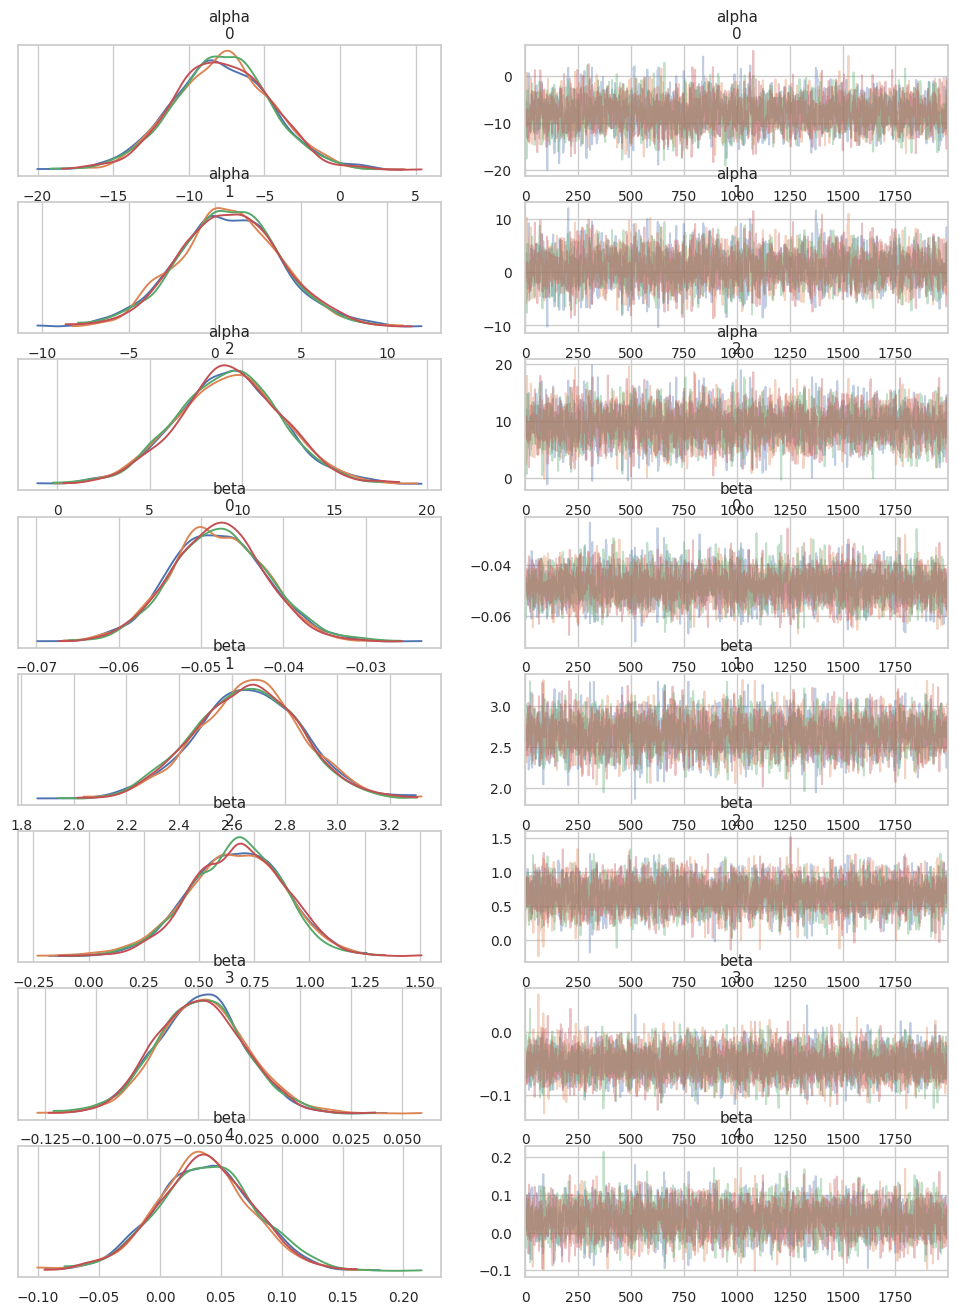

In [70]:
az.plot_trace(new_idata, var_names=['alpha', 'beta'], compact=False)  # Trace plots for each parameter

This trace and density plot shows good mixing and convergence for all parameters, with well-overlapping chains and stable sampling behavior, indicating a reliable posterior estimation for the extended model with country and time effects.

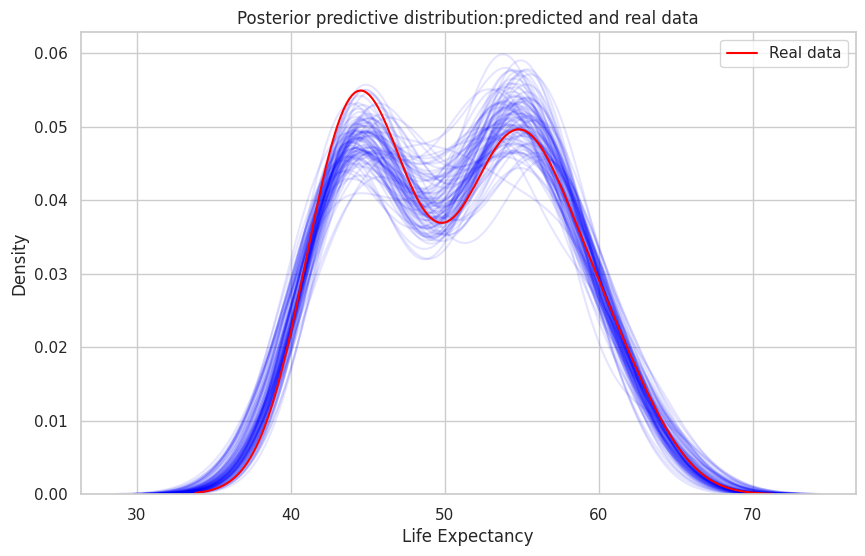

In [71]:
y_hat= new_fit.stan_variable('y_rep')
y_real = africa_subset.Life_expectancy.values

plt.figure(figsize=(10, 6))
for i in range(100):
    sns.kdeplot(y_hat[i],color='blue',alpha=0.1)
sns.kdeplot(y_real,color='red',label="Real data")
plt.xlabel("Life Expectancy")
plt.ylabel("Density")
plt.title("Posterior predictive distribution:predicted and real data")
plt.legend()
plt.show()

The posterior predictive distribution closely aligns with the real data, indicating that the model's predictions are well-calibrated and accurately capture the distribution of life expectancy values in the dataset.